### Business Question:
Predict how much revenue a customer will generate over their entire relationship with the business? CLV tells you the customer who is worth fighting to keep.
### Meaning of features
1. CustomerSegment : a classification of customers based on their purchasing behavior, value, or engagement level (e.g., Premium, Regular, New Customer).    
2. PreferredPaymentMethod: The payment option most frequently used by the customer for transactions, such as credit card, bank transfer, or digital wallet.        
3. CustomerTenure_Months : The total number of months the customer has maintained a relationship with the business.                                                
4. Recency_Days : The number of days since the customer’s last purchase or interaction with the business.                                                 
5. PurchaseFrequency : The rate at which a customer makes purchases within a specific period.                                                                    
6. AvgOrderValue : The average amount of money spent by the customer per transaction.                                                                       
7. TotalRevenue : The cumulative revenue generated from the customer over their relationship with the business.                                            
8. TotalItemsBought : The total quantity of products or items purchased by the customer.                                                                       
9. TotalReturns : The total number of purchased items that the customer returned.                                                                           
10. FavouriteCategory : The product category most frequently purchased or preferred by the customer.                                                             
11. CLV: Customer Lifetime Value : the estimated total revenue a customer is expected to generate throughout their relationship with the business.                                                                                                             
12. Region  :The geographical location or area where the customer resides or primarily conducts transactions.                                          


#### Data Collection & Data Understanding

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df = pd.read_csv("Ecommerce_CLV_Dataset.csv")
df.head()

,CustomerID,Gender,Age,Region,CustomerSegment,PreferredPaymentMethod,CustomerTenure_Months,Recency_Days,PurchaseFrequency,AvgOrderValue,TotalRevenue,TotalItemsBought,TotalReturns,FavouriteCategory,CLV
0,CUST_0001,Male,34,Europe,Budget,Debit Card,39.1,946,5,79.87,399.35,14,0,Beauty,122.56
1,CUST_0002,Female,26,Asia,Mid-Range,Credit Card,57.1,476,4,425.29,1701.17,12,1,Beauty,312.82
2,CUST_0003,Male,50,North America,Mid-Range,Credit Card,60.1,169,5,223.21,1116.07,9,2,Beauty,178.27
3,CUST_0004,Male,37,Asia,Mid-Range,Debit Card,35.6,186,7,616.97,4318.77,27,0,Electronics,1455.77
4,CUST_0005,Male,30,Asia,Mid-Range,Bank Transfer,51.5,375,5,456.56,2282.82,13,1,Electronics,478.72


In [4]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Region', 'CustomerSegment',
       'PreferredPaymentMethod', 'CustomerTenure_Months', 'Recency_Days',
       'PurchaseFrequency', 'AvgOrderValue', 'TotalRevenue',
       'TotalItemsBought', 'TotalReturns', 'FavouriteCategory', 'CLV'],
      dtype='str')

In [5]:
df.shape

(1000, 15)

We have 1000 instances and 15 attributes in the dataset

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CustomerID              1000 non-null   str    
 1   Gender                  1000 non-null   str    
 2   Age                     1000 non-null   int64  
 3   Region                  1000 non-null   str    
 4   CustomerSegment         1000 non-null   str    
 5   PreferredPaymentMethod  1000 non-null   str    
 6   CustomerTenure_Months   1000 non-null   float64
 7   Recency_Days            1000 non-null   int64  
 8   PurchaseFrequency       1000 non-null   int64  
 9   AvgOrderValue           1000 non-null   float64
 10  TotalRevenue            1000 non-null   float64
 11  TotalItemsBought        1000 non-null   int64  
 12  TotalReturns            1000 non-null   int64  
 13  FavouriteCategory       1000 non-null   str    
 14  CLV                     1000 non-null   float64
dtyp

### Frequency count of the categorical attributes

In [10]:
col_names = ["Gender","Region","CustomerSegment","PreferredPaymentMethod","FavouriteCategory"]
for col in col_names :
    print(df[col].value_counts())

Gender
Female    510
Male      490
Name: count, dtype: int64
Region
South America    214
Europe           210
Africa           210
North America    191
Asia             175
Name: count, dtype: int64
CustomerSegment
Mid-Range    401
Budget       387
Premium      212
Name: count, dtype: int64
PreferredPaymentMethod
Credit Card      261
PayPal           253
Debit Card       250
Bank Transfer    236
Name: count, dtype: int64
FavouriteCategory
Beauty            239
Books             173
Electronics       137
Fashion           102
Home & Garden      91
Toys               87
Food & Grocery     87
Sports             74
Unknown            10
Name: count, dtype: int64


#### Summary of variables
We have 5 major categorical attributes in the dataset and CLV is the target variablr

#### Data Cleaning & Preprocessinng

In [12]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Region                    0
CustomerSegment           0
PreferredPaymentMethod    0
CustomerTenure_Months     0
Recency_Days              0
PurchaseFrequency         0
AvgOrderValue             0
TotalRevenue              0
TotalItemsBought          0
TotalReturns              0
FavouriteCategory         0
CLV                       0
dtype: int64

We don't have missing values in the dataset

In [ ]:
# Check for Duplicates
df.duplicated().sum()

np.int64(0)

In [17]:
#### Drop the unique identifier
df.drop("CustomerID", axis =1, inplace = True)

In [18]:
df.columns

Index(['Gender', 'Age', 'Region', 'CustomerSegment', 'PreferredPaymentMethod',
       'CustomerTenure_Months', 'Recency_Days', 'PurchaseFrequency',
       'AvgOrderValue', 'TotalRevenue', 'TotalItemsBought', 'TotalReturns',
       'FavouriteCategory', 'CLV'],
      dtype='str')

#### Statistical summary

In [19]:
df.describe()

,Age,CustomerTenure_Months,Recency_Days,PurchaseFrequency,AvgOrderValue,TotalRevenue,TotalItemsBought,TotalReturns,CLV
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,43.799000,44.202400,282.330000,5.000000,678.791080,3435.726810,15.045000,0.632000,925.637280
std,15.133857,9.647946,272.782179,2.230465,840.419592,4765.031777,7.458727,0.810699,1349.284416
min,18.000000,27.600000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,31.000000,35.800000,84.750000,3.000000,124.032500,592.377500,10.000000,0.000000,149.647500
50%,44.000000,44.300000,196.000000,5.000000,353.345000,1480.765000,14.000000,0.000000,366.120000
75%,57.000000,52.600000,388.250000,6.000000,623.660000,3562.120000,20.000000,1.000000,985.270000
max,69.000000,60.900000,1445.000000,13.000000,3736.490000,27744.710000,51.000000,5.000000,9458.430000


### E.D.A
Lets explore the data to uncover insights

In [21]:
numeric_cols = df.select_dtypes( include =["number"])

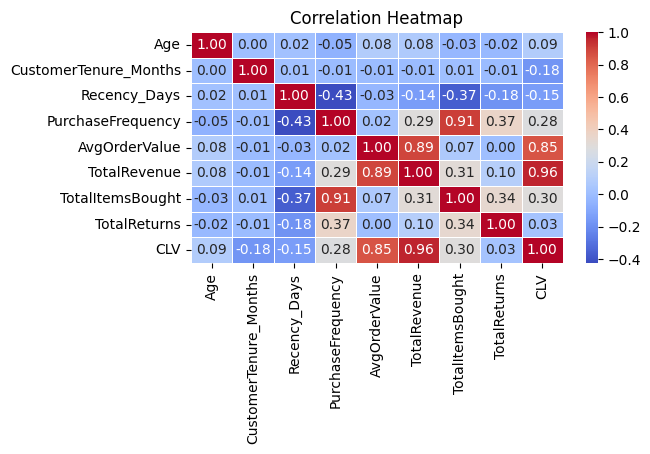

In [22]:
corr_matrix = numeric_cols.corr()
# Plot heatmap
plt.figure(figsize=(6, 3))
sns.heatmap(corr_matrix, annot=True,cmap='coolwarm', fmt='.2f',linewidths=0.5)

plt.title("Correlation Heatmap")
plt.show()

#### Revenue by region

In [26]:
df.columns

Index(['Gender', 'Age', 'Region', 'CustomerSegment', 'PreferredPaymentMethod',
       'CustomerTenure_Months', 'Recency_Days', 'PurchaseFrequency',
       'AvgOrderValue', 'TotalRevenue', 'TotalItemsBought', 'TotalReturns',
       'FavouriteCategory', 'CLV'],
      dtype='str')

In [27]:
df.groupby("CustomerSegment")["TotalRevenue"]\
    .sum()\
    .reset_index()\
    .sort_values(by="TotalRevenue", ascending=False)\
    .head(10)

,CustomerSegment,TotalRevenue
2,Premium,2315979.02
1,Mid-Range,903358.48
0,Budget,216389.31


In [28]:
df.groupby("Gender")["TotalRevenue"]\
    .sum()\
    .reset_index()\
    .sort_values(by="TotalRevenue", ascending=False)\
    .head(10)

,Gender,TotalRevenue
0,Female,1755207.36
1,Male,1680519.45


In [ ]:
# customer segmentation by average order value
df.groupby("CustomerSegment")["AvgOrderValue"]\
    .sum()\
    .reset_index()\
    .sort_values(by="AvgOrderValue", ascending=False)\
    .head(10)

,CustomerSegment,AvgOrderValue
2,Premium,455567.05
1,Mid-Range,180342.47
0,Budget,42881.56


In [30]:
# Items bought by gender
df.groupby("Gender")["TotalItemsBought"]\
    .sum()\
    .reset_index()\
    .sort_values(by="TotalItemsBought", ascending=False)\
    .head(10)

,Gender,TotalItemsBought
0,Female,7757
1,Male,7288


The female customers bought more items than the male

In [34]:
# Items bought by gender
df.groupby("FavouriteCategory")["TotalItemsBought"]\
    .sum()\
    .reset_index()\
    .sort_values(by="TotalItemsBought", ascending=False)\
    .head(8)

,FavouriteCategory,TotalItemsBought
0,Beauty,3564
1,Books,2519
2,Electronics,2074
3,Fashion,1626
5,Home & Garden,1455
4,Food & Grocery,1410
7,Toys,1262
6,Sports,1135


Items from the beauty category was purchased more than other items

#### Data Visualization

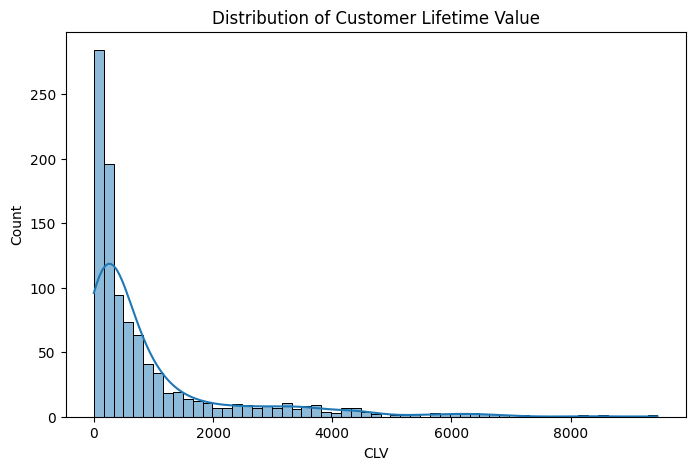

In [ ]:
# Distribution of customer lifetime value
plt.figure(figsize=(8,5))

sns.histplot(df['CLV'], kde=True)

plt.title("Distribution of Customer Lifetime Value")
plt.xlabel("CLV")
plt.show()

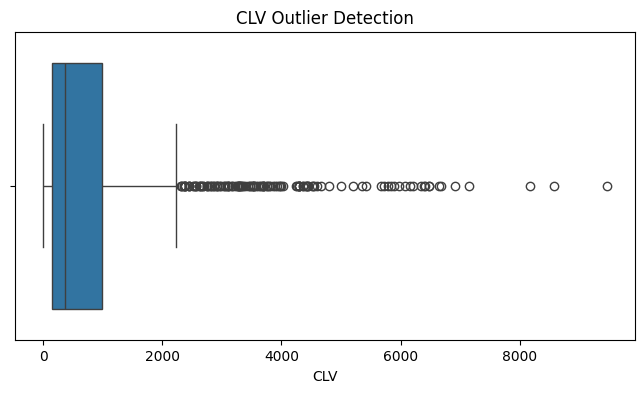

In [ ]:
# CLV Outlier detection
plt.figure(figsize=(8,4))

sns.boxplot(x=df['CLV'])

plt.title("CLV Outlier Detection")
plt.show()

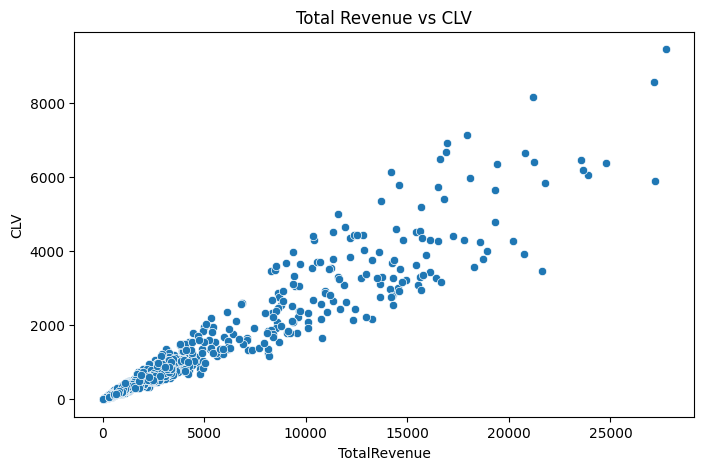

In [ ]:
# Total Revenue by CLV
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='TotalRevenue',y='CLV')

plt.title("Total Revenue vs CLV")
plt.show()

There is a strong linear relationship between Total Revenue and CLV, if we use both features to build a model it will lead to a potentital data leakage

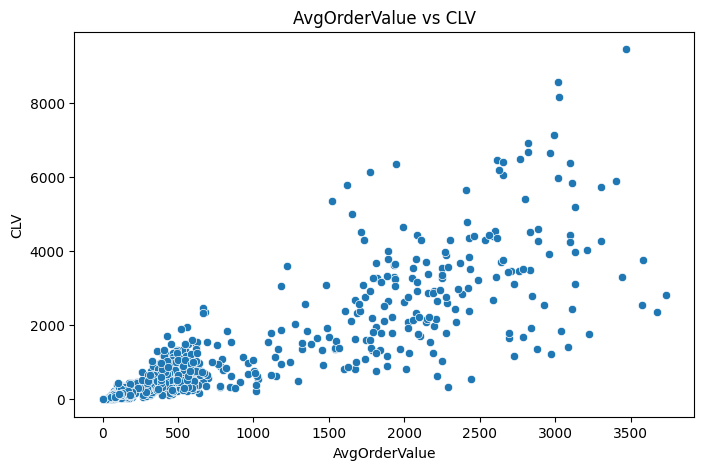

In [41]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='AvgOrderValue',y='CLV')

plt.title("AvgOrderValue vs CLV")
plt.show()

<Figure size 800x500 with 0 Axes>

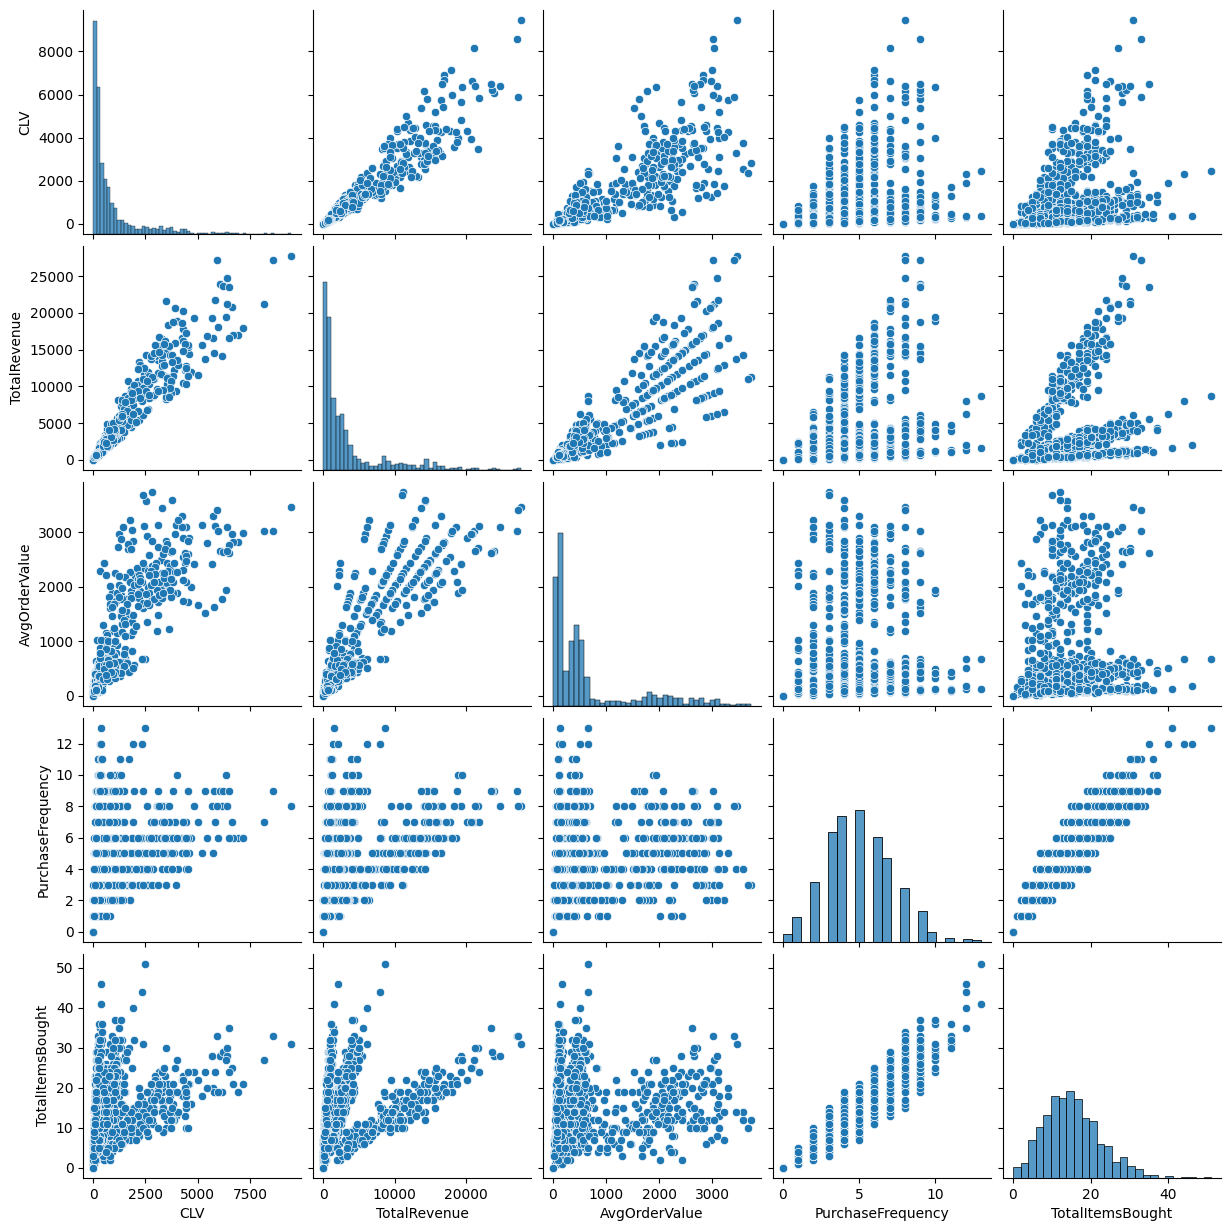

In [ ]:
# Pairplot of important features
plt.figure(figsize=(8,5))
sns.pairplot(df[['CLV', 'TotalRevenue','AvgOrderValue','PurchaseFrequency', 'TotalItemsBought']])

plt.show()

### CLV By customer segmentation

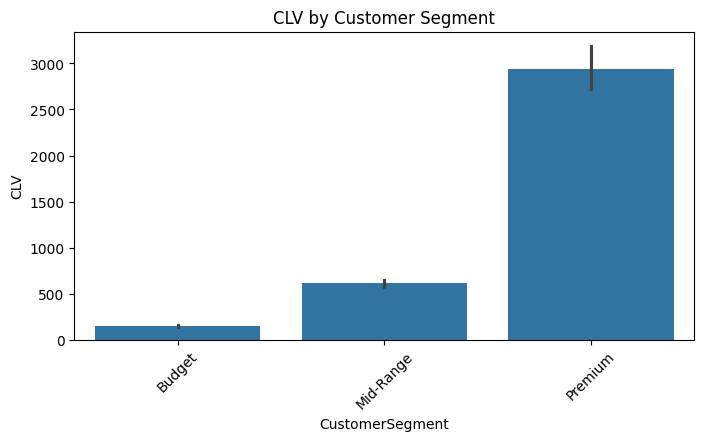

In [ ]:
plt.figure(figsize=(8,4))
sns.barplot(data=df,x='CustomerSegment', y='CLV')

plt.title("CLV by Customer Segment")
plt.xticks(rotation=45)
plt.show()

#### CLV by Region

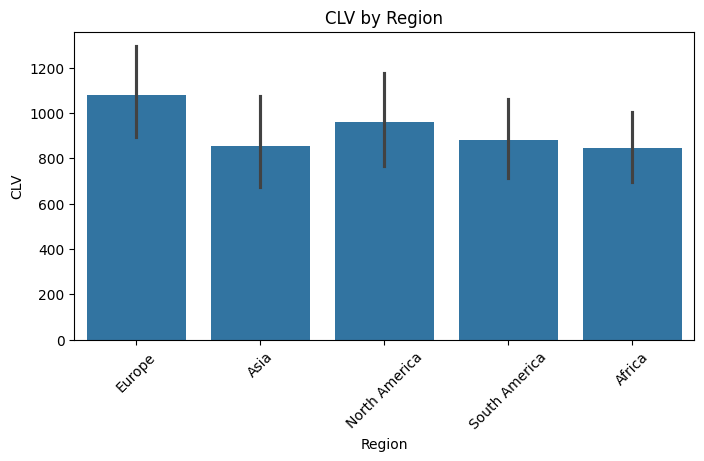

In [51]:
plt.figure(figsize=(8,4))
sns.barplot( data=df,x='Region', y='CLV')

plt.title("CLV by Region")
plt.xticks(rotation=45)
plt.show()

#### CLV by customer segment

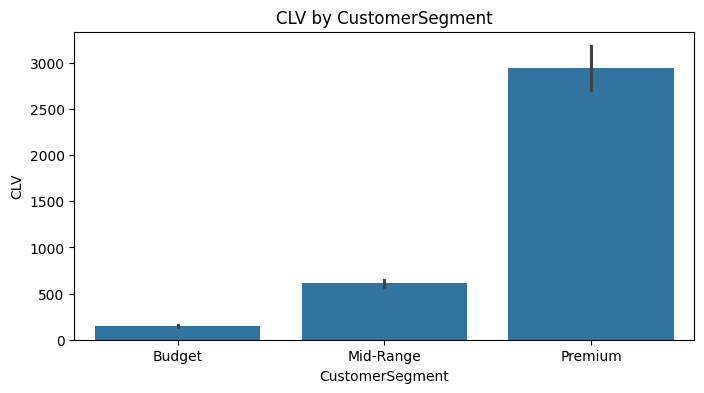

In [ ]:
# CLV by customer segment
plt.figure(figsize=(8,4))
sns.barplot(data=df,x="CustomerSegment",y="CLV")
plt.title("CLV by CustomerSegment")
plt.show()

Customers on Premium segment has the highest customer lifetime value (CLV)

#### Outlier Treatment
Outliers are data points that differs from the rest of the data

In [57]:
# Check correlation with target variable
df.corr(numeric_only=True)["CLV"].sort_values(ascending=False)

CLV                      1.000000
TotalRevenue             0.955489
AvgOrderValue            0.854505
TotalItemsBought         0.297406
PurchaseFrequency        0.279860
Age                      0.086691
TotalReturns             0.028622
Recency_Days            -0.145053
CustomerTenure_Months   -0.175236
Name: CLV, dtype: float64

Total Revenue  and Average Order value are highly correlated with the target variable, we can use any of them as datasource when handling outliers

#### check statistical summary

In [58]:
# check statistical summary
df.describe()

,Age,CustomerTenure_Months,Recency_Days,PurchaseFrequency,AvgOrderValue,TotalRevenue,TotalItemsBought,TotalReturns,CLV
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,43.799000,44.202400,282.330000,5.000000,678.791080,3435.726810,15.045000,0.632000,925.637280
std,15.133857,9.647946,272.782179,2.230465,840.419592,4765.031777,7.458727,0.810699,1349.284416
min,18.000000,27.600000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,31.000000,35.800000,84.750000,3.000000,124.032500,592.377500,10.000000,0.000000,149.647500
50%,44.000000,44.300000,196.000000,5.000000,353.345000,1480.765000,14.000000,0.000000,366.120000
75%,57.000000,52.600000,388.250000,6.000000,623.660000,3562.120000,20.000000,1.000000,985.270000
max,69.000000,60.900000,1445.000000,13.000000,3736.490000,27744.710000,51.000000,5.000000,9458.430000


#### Visualize the outlier

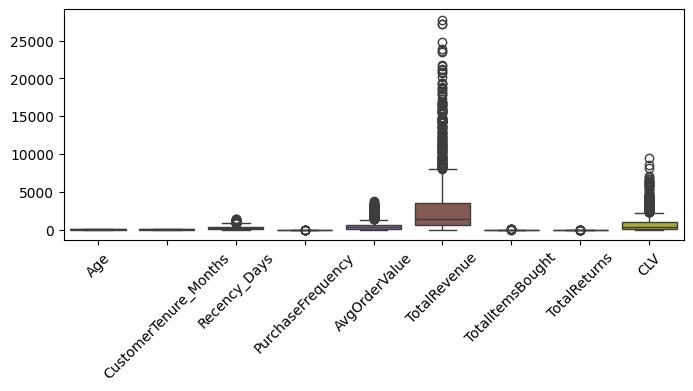

In [59]:
#Visualize the outlier
import seaborn as sns
figure = plt.figure(figsize= (8,3))
sns.boxplot(data=df)
plt.xticks(rotation = 45)
plt.show()

#### Applying InterQuartileRange(IQR) to the Outlier
 Using TotalRevenue as the datasource

In [62]:
Q1 = df["TotalRevenue"].quantile(0.25)
Q3 = df["TotalRevenue"].quantile(0.75)
Q1 , Q3

(np.float64(592.3775), np.float64(3562.12))

In [ ]:
IQR = Q3 - Q1
lowerlimit = Q1 - 1.5*IQR
upperlimit = Q3 + 1.5 *IQR
lowerlimit , upperlimit

(np.float64(-3862.2362499999995), np.float64(8016.733749999999))

A negative lower bound of -$3,862 for TotalRevenue is illogical because revenue cannot be negative in business contexts.

In [ ]:
# Check Total Revenue Skewness
df['TotalRevenue'].skew()

np.float64(2.2333103657319175)

The  highly right skewed data of 2.33 is what caused the wide IQR spread

In [83]:
# check AvgOrderValue skewness
df['AvgOrderValue'].skew()

np.float64(1.6676696874253971)

The AvgOrderValue is also right skewed , we have to transform it before using it as datasource for outlier treatment

#### Handling Skewness using Data Transformation

https://www.geeksforgeeks.org/data-science/skewness-measures-and-interpretation/

In [93]:
from scipy.stats import boxcox

# Check sqrt skewness 
print(f"Sqrt Skewness of Total Revenue: {np.sqrt(df['TotalRevenue']).skew()}")

# Check cuberoot skewness 
print(f"Cbrt Skewness of Total Revenue: {np.cbrt(df['TotalRevenue']).skew()}")

# Check Box-Cox skewness 
transformed, best_lambda = boxcox(df['TotalRevenue'] + 1)
print(f"Box-Cox Skewness of Total Revenue: {pd.Series(transformed).skew()}")
print(f"Best Lambda: {best_lambda}")


Sqrt Skewness of Total Revenue: 1.2533756650870889
Cbrt Skewness of Total Revenue: 0.8074325320686968
Box-Cox Skewness of Total Revenue: 0.04505706806479251
Best Lambda: 0.13263523038305847


In [94]:
# Check sqrt skewness of AvgOrderValue
print(f"Sqrt Skewness of AvgOrderValue: {np.sqrt(df['AvgOrderValue']).skew()}")

# Check cuberoot skewness of AvgOrderValue
print(f"Cbrt Skewness of AvgOrderValue: {np.cbrt(df['AvgOrderValue']).skew()}")
# Box-cox skewness of AvgOrderValue
transformed, best_lambda = boxcox(df['AvgOrderValue'] + 1)
print(f"Box-Cox Skewness of Total AvgOrderValue: {pd.Series(transformed).skew()}")
print(f"Best Lambda: {best_lambda}")

Sqrt Skewness of AvgOrderValue: 1.048736719160349
Cbrt Skewness of AvgOrderValue: 0.6985996202814048
Box-Cox Skewness of Total AvgOrderValue: 0.022476121055548293
Best Lambda: 0.09935180206446105


IQR is more effective when the data source skewness is btw 0 to 0.5. We wil make use of the AvgOrderValue box-cox in handling the outlier

In [91]:
df['AvgOrderValue_boxcox'], avgorder_lambda = boxcox(df['AvgOrderValue'] + 1)

In [96]:
df.columns

Index(['Gender', 'Age', 'Region', 'CustomerSegment', 'PreferredPaymentMethod',
       'CustomerTenure_Months', 'Recency_Days', 'PurchaseFrequency',
       'AvgOrderValue', 'TotalRevenue', 'TotalItemsBought', 'TotalReturns',
       'FavouriteCategory', 'CLV', 'AvgOrderValue_boxcox'],
      dtype='str')

#### Using AvgOrderValue as the datasource for handling outlier

In [97]:
Q1 = df["AvgOrderValue_boxcox"].quantile(0.25)
Q3 = df["AvgOrderValue_boxcox"].quantile(0.75)
Q1 , Q3

(np.float64(6.196506384450556), np.float64(9.014673995957388))

In [98]:
IQR = Q3 - Q1
lowerlimit = Q1 - 1.5*IQR
upperlimit = Q3 + 1.5 *IQR
lowerlimit , upperlimit

(np.float64(1.9692549671903086), np.float64(13.241925413217636))

In [99]:
# Shape of the data set before outlier removal
df.shape

(1000, 15)

In [100]:
#OUTLIERS
len(df[(df.AvgOrderValue_boxcox > upperlimit) | (df.AvgOrderValue_boxcox < lowerlimit)] )

10

We have 10 outliers in the dataset

In [103]:
# REMOVE OUTLIERS - Keep only rows within bounds
df_no_outliers = df[(df.AvgOrderValue_boxcox >= lowerlimit) &  (df.AvgOrderValue_boxcox <= upperlimit)]
print(f"Original rows: {len(df)}, After outlier removal: {len(df_no_outliers)}")
print(f"Rows removed: {len(df) - len(df_no_outliers)}")

Original rows: 1000, After outlier removal: 990
Rows removed: 10


#### Declare Feature Vector and Target Variable

In [107]:
df.columns

Index(['Gender', 'Age', 'Region', 'CustomerSegment', 'PreferredPaymentMethod',
       'CustomerTenure_Months', 'Recency_Days', 'PurchaseFrequency',
       'AvgOrderValue', 'TotalRevenue', 'TotalItemsBought', 'TotalReturns',
       'FavouriteCategory', 'CLV', 'AvgOrderValue_boxcox'],
      dtype='str')

In [108]:
X = df_no_outliers[["Gender","Age","Region","CustomerSegment","CustomerTenure_Months","Recency_Days","PurchaseFrequency","AvgOrderValue_boxcox","TotalItemsBought","TotalReturns","FavouriteCategory"]]
y = df_no_outliers["CLV"]

#### Feature Engineering

Encoding using lambda

In [110]:
X["Gender"]= X["Gender"].apply(lambda x:1 if x== "Female" else 0)

In [113]:
X.info()

<class 'pandas.DataFrame'>
Index: 990 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Gender                 990 non-null    int64  
 1   Age                    990 non-null    int64  
 2   Region                 990 non-null    str    
 3   CustomerSegment        990 non-null    str    
 4   CustomerTenure_Months  990 non-null    float64
 5   Recency_Days           990 non-null    int64  
 6   PurchaseFrequency      990 non-null    int64  
 7   AvgOrderValue_boxcox   990 non-null    float64
 8   TotalItemsBought       990 non-null    int64  
 9   TotalReturns           990 non-null    int64  
 10  FavouriteCategory      990 non-null    str    
dtypes: float64(2), int64(6), str(3)
memory usage: 116.1 KB


In [112]:
categorical_columns = X[["Region","CustomerSegment","FavouriteCategory"]]
for col in categorical_columns:
    print(X[col].value_counts())

Region
South America    213
Europe           209
Africa           209
North America    185
Asia             174
Name: count, dtype: int64
CustomerSegment
Mid-Range    395
Budget       384
Premium      211
Name: count, dtype: int64
FavouriteCategory
Beauty            239
Books             173
Electronics       137
Fashion           102
Home & Garden      91
Toys               87
Food & Grocery     87
Sports             74
Name: count, dtype: int64


#### Encoding using Mapping

In [ ]:
X["Region"] = X['Region'].map({'South America':1,'Europe':2,'Africa':3,'North America':4,'Asia':5})

In [115]:
X["Region"].dtypes

dtype('int64')

In [116]:
X["FavouriteCategory"] = X['FavouriteCategory'].map({'Beauty':1,'Books':2,'Electronics':3,'Fashion':4,'Home & Garden':5,'Toys':6, 'Food & Grocery':7,'Sports':8})

In [117]:
X["FavouriteCategory"].dtypes

dtype('int64')

#### Using Ordinal Encoding

In [118]:
from sklearn.preprocessing import OrdinalEncoder

segment_order = [['Budget', 'Mid-Range', 'Premium']]

encoder = OrdinalEncoder(categories=segment_order)

# Encode and convert to integer values starting from 1
X['CustomerSegment'] = (encoder.fit_transform(X[['CustomerSegment']]).astype(int).ravel() + 1)

In [120]:
X.info()

<class 'pandas.DataFrame'>
Index: 990 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Gender                 990 non-null    int64  
 1   Age                    990 non-null    int64  
 2   Region                 990 non-null    int64  
 3   CustomerSegment        990 non-null    int64  
 4   CustomerTenure_Months  990 non-null    float64
 5   Recency_Days           990 non-null    int64  
 6   PurchaseFrequency      990 non-null    int64  
 7   AvgOrderValue_boxcox   990 non-null    float64
 8   TotalItemsBought       990 non-null    int64  
 9   TotalReturns           990 non-null    int64  
 10  FavouriteCategory      990 non-null    int64  
dtypes: float64(2), int64(9)
memory usage: 92.8 KB


#### Split Data Into Seperate Training and Test Set

In [121]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.3)

#### Linear Regression Model

In [123]:
# import Linear regression model
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

# Print coefficients
print(f"Intercept: {model.intercept_}")
print(f"Coefficient: {model.coef_[0]}")

Intercept: -3076.4071316939066
Coefficient: -80.72509657185306


In [124]:
y_pred = model.predict(X_test)

#### Model Evaluation

In [127]:
from sklearn.metrics import mean_squared_error, r2_score
mse_lr = mean_squared_error(y_test, y_pred)
r2_lr = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse_lr}")
print(f"R² Score: {r2_lr}")

Mean Squared Error: 461407.5717441525
R² Score: 0.6739601822150686


### Random forest Regressor

In [135]:
# Import the model
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=200)
model = rf_model.fit(X_train, y_train)

In [136]:
y_pred = model.predict(X_test)

### Model Evaluation

In [137]:
from sklearn.metrics import mean_squared_error, r2_score
mse_rfr = mean_squared_error(y_test, y_pred)
r2_rfr = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse_rfr}")
print(f"R² Score: {r2_rfr}")

Mean Squared Error: 74417.16172420452
R² Score: 0.9474153452729097


#### Evaluation and comparison for all models

In [139]:
models = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest Regressor'],
    'MSE': [mse_lr,mse_rfr],
    'R^2' : [r2_lr,r2_rfr]
    })
models.sort_values(by='MSE',ascending=True) 

,Model,MSE,R^2
1,Random Forest Regressor,74417.161724,0.947415
0,Linear Regression,461407.571744,0.673960


##### The Randoom Forest Regressor model explains  94.7% of the variation in Customer Lifetime Value (CLV).

In [140]:
import joblib

joblib.dump(rf_model, "rf_clv_model.pkl")

['rf_clv_model.pkl']